In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q
!pip install kagglehub -q
print('✅ Dependencies Installed')

✅ Dependencies Installed


In [2]:
# ✅ STEP 2: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay,
    f1_score, cohen_kappa_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [3]:
# ✅ STEP 3: Load USGS Earthquake Dataset from Kaggle
path = kagglehub.dataset_download("usgs/earthquake-database")
print("Files:", os.listdir(path))

df_raw = pd.read_csv(f"{path}/database.csv")
print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())

100%|██████████| 590k/590k [00:00<00:00, 37.5MB/s]

Extracting files...
Files: ['database.csv']


Shape: (23412, 21)
Columns: ['Date', 'Time', 'Latitude', 'Longitude', 'Type', 'Depth', 'Depth Error', 'Depth Seismic Stations', 'Magnitude', 'Magnitude Type', 'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap', 'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID', 'Source', 'Location Source', 'Magnitude Source', 'Status']


In [5]:
# ✅ STEP 3b: Clean and prepare data
# Rename columns to lowercase with underscores for consistency
df = df_raw[['Latitude', 'Longitude', 'Depth', 'Magnitude',
             'Magnitude Type', 'Depth Error', 'Magnitude Error',
             'Azimuthal Gap', 'Horizontal Distance',
             'Root Mean Square']].copy()

df.columns = ['latitude', 'longitude', 'depth_km', 'magnitude',
              'mag_type', 'depth_error', 'mag_error',
              'azimuthal_gap', 'horizontal_distance',
              'rms']

# Drop rows with missing Magnitude or Depth
df = df.dropna(subset=['magnitude', 'depth_km'])

print(f"Cleaned shape: {df.shape}")
print(f"Magnitude range: {df['magnitude'].min()} to {df['magnitude'].max()}")
print(df['magnitude'].describe())

Cleaned shape: (23412, 10)
Magnitude range: 5.5 to 9.1
count    23412.000000
mean         5.882531
std          0.423066
min          5.500000
25%          5.600000
50%          5.700000
75%          6.000000
max          9.100000
Name: magnitude, dtype: float64


In [6]:
# ✅ STEP 4: Create REALISTIC damage labels (fixing data leakage)

def compute_damage_score(row):
    """Compute a continuous damage score with noise to prevent data leakage.

    The score is based on seismological principles:
    - Higher magnitude = more energy = more damage
    - Shallower depth = more surface impact = more damage
    - Location contributes some variance (different regions have different vulnerability)

    Crucially, we add significant random noise to simulate unmeasured factors
    (building quality, local soil, population density, infrastructure, etc.).
    This prevents the model from perfectly memorizing the label rules.
    """
    mag = row['magnitude']
    dep = row['depth_km']
    lat = row['latitude']
    lon = row['longitude']

    # Base score from magnitude (non-linear: energy scales exponentially)
    mag_score = np.exp((mag - 5.5) * 1.2)  # Exponential scaling

    # Depth factor: shallow quakes do more damage (inverse relationship)
    depth_factor = 1.0 / (1.0 + dep / 50.0)  # Sigmoid-like decay

    # Location-based vulnerability factor (simplified: uses lat/lon hash for variety)
    # This adds geographic variability without being perfectly predictable
    location_factor = 0.7 + 0.6 * np.sin(lat * 0.1) * np.cos(lon * 0.1)

    # Combine factors
    base_score = mag_score * depth_factor * location_factor

    # Add significant random noise (simulates unmeasured real-world factors)
    # This is the KEY fix: noise prevents perfect memorization
    noise = np.random.normal(0, base_score * 0.4)  # 40% relative noise
    final_score = base_score + noise

    return max(final_score, 0)  # Ensure non-negative


# Compute continuous damage scores
np.random.seed(42)  # For reproducibility
df['damage_score'] = df.apply(compute_damage_score, axis=1)

# Convert to categorical labels using percentile-based thresholds
# This gives us better class balance than fixed thresholds
low_threshold = df['damage_score'].quantile(0.55)    # Bottom 55% = Low
high_threshold = df['damage_score'].quantile(0.85)   # Top 15% = High

def score_to_label(score):
    if score <= low_threshold:
        return 0  # Low
    elif score <= high_threshold:
        return 1  # Medium
    else:
        return 2  # High

df['damage_level'] = df['damage_score'].apply(score_to_label)

# Drop the intermediate score column (it's the label source, so we don't train on it)
df = df.drop(columns=['damage_score'])

print('✅ Damage labels created (with noise to prevent data leakage)')
print(f'\nClass distribution:')
counts = df['damage_level'].value_counts().sort_index()
labels_map = {0: 'Low', 1: 'Medium', 2: 'High'}
for idx, count in counts.items():
    pct = count / len(df) * 100
    print(f'  {labels_map[idx]:8s}: {count:6d} ({pct:.1f}%)')
print(f'  {"Total":8s}: {len(df):6d}')

✅ Damage labels created (with noise to prevent data leakage)

Class distribution:
  Low     :  12877 (55.0%)
  Medium  :   7023 (30.0%)
  High    :   3512 (15.0%)
  Total   :  23412


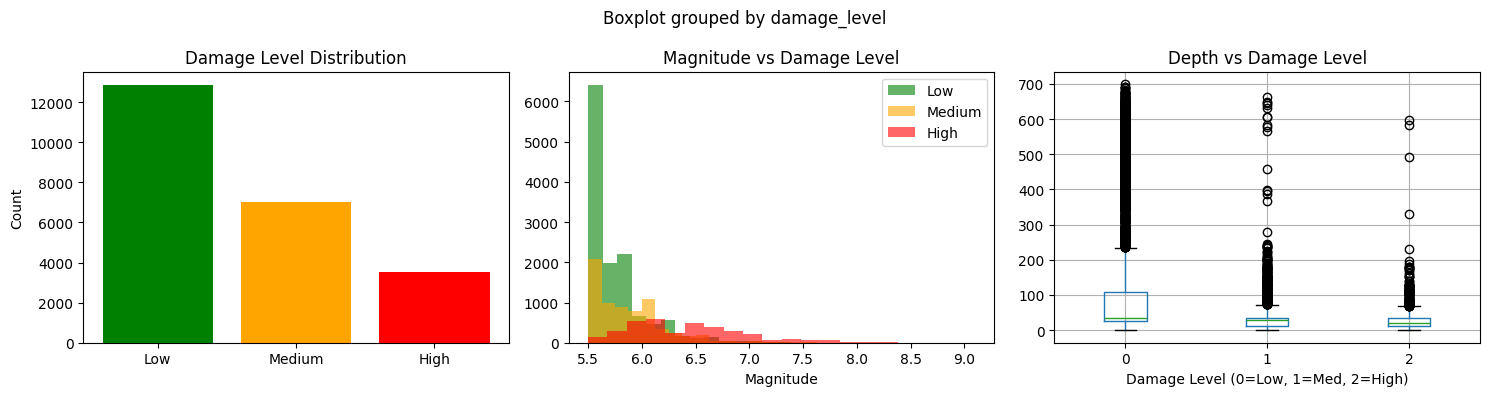

✅ EDA complete!


In [7]:
# ✅ STEP 5: EDA - Visualize the data

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Earthquake Dataset - EDA', fontsize=14, fontweight='bold')

# Plot 1: Damage distribution
damage_counts = df['damage_level'].value_counts().sort_index()
axes[0].bar(['Low', 'Medium', 'High'], damage_counts.values, color=['green','orange','red'])
axes[0].set_title('Damage Level Distribution')
axes[0].set_ylabel('Count')

# Plot 2: Magnitude vs Damage
for level, color, label in zip([0,1,2], ['green','orange','red'], ['Low','Medium','High']):
    axes[1].hist(df[df['damage_level']==level]['magnitude'],
                 alpha=0.6, label=label, color=color, bins=20)
axes[1].set_title('Magnitude vs Damage Level')
axes[1].set_xlabel('Magnitude')
axes[1].legend()

# Plot 3: Depth vs Damage
df.boxplot(column='depth_km', by='damage_level', ax=axes[2])
axes[2].set_title('Depth vs Damage Level')
axes[2].set_xlabel('Damage Level (0=Low, 1=Med, 2=High)')

plt.tight_layout()
plt.show()
print('✅ EDA complete!')

In [8]:
# ✅ STEP 6: Feature Engineering & Train/Test Split

# Engineer additional features from the raw data
df['abs_latitude'] = df['latitude'].abs()  # Distance from equator
df['mag_depth_ratio'] = df['magnitude'] / (df['depth_km'] + 1)  # Energy-to-depth ratio
df['log_depth'] = np.log1p(df['depth_km'])  # Log-scaled depth
df['mag_squared'] = df['magnitude'] ** 2  # Non-linear magnitude feature

# Fill NaN values in optional columns with median
for col in ['depth_error', 'mag_error', 'azimuthal_gap', 'horizontal_distance', 'rms']:
    df[col] = df[col].fillna(df[col].median())

# Encode magnitude type
le_mag_type = LabelEncoder()
df['mag_type_encoded'] = le_mag_type.fit_transform(df['mag_type'].fillna('Unknown'))

# Select features for training
feature_cols = [
    'magnitude', 'depth_km', 'latitude', 'longitude',
    'abs_latitude', 'mag_depth_ratio', 'log_depth', 'mag_squared',
    'depth_error', 'mag_error', 'azimuthal_gap', 'horizontal_distance',
    'rms', 'mag_type_encoded'
]

X = df[feature_cols].copy()
y = df['damage_level']

# Stratified split to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Features:     {X_train.shape[1]}')
print(f'\nTrain class distribution:')
for idx, count in y_train.value_counts().sort_index().items():
    print(f'  {labels_map[idx]:8s}: {count:5d} ({count/len(y_train)*100:.1f}%)')
print(f'\nTest class distribution:')
for idx, count in y_test.value_counts().sort_index().items():
    print(f'  {labels_map[idx]:8s}: {count:5d} ({count/len(y_test)*100:.1f}%)')

Training set: 18729 samples
Test set:     4683 samples
Features:     14

Train class distribution:
  Low     : 10301 (55.0%)
  Medium  :  5618 (30.0%)
  High    :  2810 (15.0%)

Test class distribution:
  Low     :  2576 (55.0%)
  Medium  :  1405 (30.0%)
  High    :   702 (15.0%)


In [9]:
# ✅ STEP 7: Train XGBoost with class weights (Primary Model)

# Compute sample weights to handle class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.5,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1_macro = f1_score(y_test, xgb_preds, average='macro')
xgb_f1_weighted = f1_score(y_test, xgb_preds, average='weighted')
xgb_kappa = cohen_kappa_score(y_test, xgb_preds)

print(f'🔥 XGBoost Results:')
print(f'   Accuracy:         {xgb_acc*100:.2f}%')
print(f'   F1-Score (macro): {xgb_f1_macro:.4f}  ← Primary metric')
print(f'   F1-Score (weighted): {xgb_f1_weighted:.4f}')
print(f'   Cohen Kappa:      {xgb_kappa:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, xgb_preds, target_names=['Low','Medium','High']))

🔥 XGBoost Results:
   Accuracy:         70.06%
   F1-Score (macro): 0.6760  ← Primary metric
   F1-Score (weighted): 0.7084
   Cohen Kappa:      0.5100

Classification Report:
              precision    recall  f1-score   support

         Low       0.87      0.74      0.80      2576
      Medium       0.53      0.60      0.56      1405
        High       0.60      0.75      0.67       702

    accuracy                           0.70      4683
   macro avg       0.67      0.70      0.68      4683
weighted avg       0.73      0.70      0.71      4683



In [10]:
# ✅ STEP 8: Train Random Forest (Backup/Comparison Model)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',  # Built-in class weight handling
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1_macro = f1_score(y_test, rf_preds, average='macro')
rf_f1_weighted = f1_score(y_test, rf_preds, average='weighted')
rf_kappa = cohen_kappa_score(y_test, rf_preds)

print(f'🌲 Random Forest Results:')
print(f'   Accuracy:         {rf_acc*100:.2f}%')
print(f'   F1-Score (macro): {rf_f1_macro:.4f}  ← Primary metric')
print(f'   F1-Score (weighted): {rf_f1_weighted:.4f}')
print(f'   Cohen Kappa:      {rf_kappa:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_preds, target_names=['Low','Medium','High']))

🌲 Random Forest Results:
   Accuracy:         66.67%
   F1-Score (macro): 0.6506  ← Primary metric
   F1-Score (weighted): 0.6771
   Cohen Kappa:      0.4660

Classification Report:
              precision    recall  f1-score   support

         Low       0.87      0.67      0.75      2576
      Medium       0.50      0.62      0.55      1405
        High       0.56      0.76      0.65       702

    accuracy                           0.67      4683
   macro avg       0.64      0.68      0.65      4683
weighted avg       0.71      0.67      0.68      4683



In [11]:
# ✅ STEP 9: Cross-Validation for robust evaluation

print('📊 5-Fold Stratified Cross-Validation')
print('=' * 50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost CV
xgb_cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42
    ),
    X, y, cv=cv, scoring='f1_macro', n_jobs=-1
)

print(f'\nXGBoost CV F1-macro scores: {xgb_cv_scores}')
print(f'XGBoost CV F1-macro mean:  {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}')

# Random Forest CV
rf_cv_scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=300, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    X, y, cv=cv, scoring='f1_macro', n_jobs=-1
)

print(f'\nRandom Forest CV F1-macro scores: {rf_cv_scores}')
print(f'Random Forest CV F1-macro mean:  {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}')

📊 5-Fold Stratified Cross-Validation

XGBoost CV F1-macro scores: [0.67369092 0.69660436 0.69274157 0.69542545 0.68466902]
XGBoost CV F1-macro mean:  0.6886 ± 0.0086

Random Forest CV F1-macro scores: [0.63634806 0.65774191 0.65864723 0.64866592 0.66189482]
Random Forest CV F1-macro mean:  0.6527 ± 0.0093


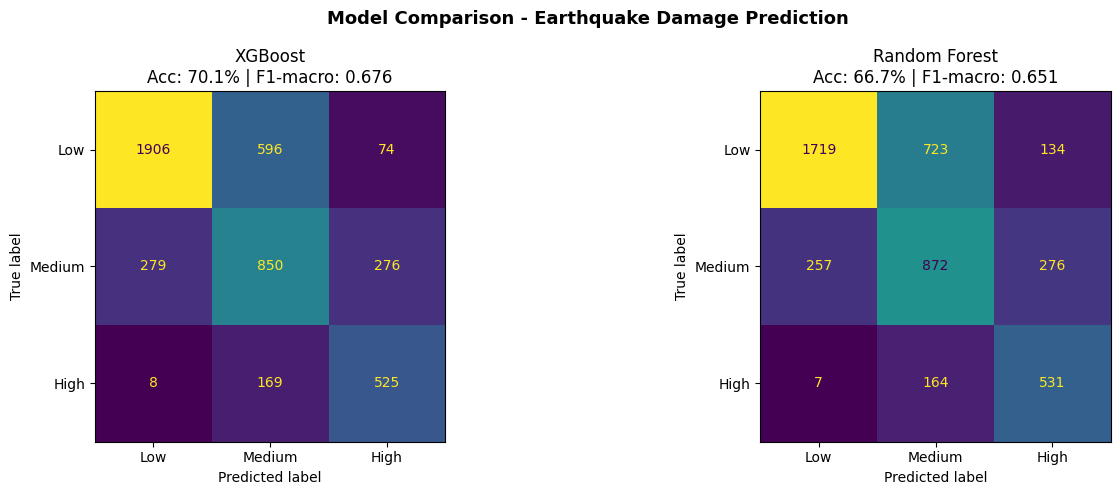


📊 SUMMARY:
   Model                  Accuracy   F1-macro      Kappa
   ──────────────────────────────────────────────────
   XGBoost                  70.06%     0.6760     0.5100
   Random Forest            66.67%     0.6506     0.4660


In [12]:
# ✅ STEP 10: Confusion Matrix + Model Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, xgb_preds),
    display_labels=['Low','Medium','High']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'XGBoost\nAcc: {xgb_acc*100:.1f}% | F1-macro: {xgb_f1_macro:.3f}')

# Random Forest confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_preds),
    display_labels=['Low','Medium','High']
).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Random Forest\nAcc: {rf_acc*100:.1f}% | F1-macro: {rf_f1_macro:.3f}')

plt.suptitle('Model Comparison - Earthquake Damage Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📊 SUMMARY:')
print(f'   {"Model":<20s} {"Accuracy":>10s} {"F1-macro":>10s} {"Kappa":>10s}')
print(f'   {"─"*50}')
print(f'   {"XGBoost":<20s} {xgb_acc*100:>9.2f}% {xgb_f1_macro:>10.4f} {xgb_kappa:>10.4f}')
print(f'   {"Random Forest":<20s} {rf_acc*100:>9.2f}% {rf_f1_macro:>10.4f} {rf_kappa:>10.4f}')

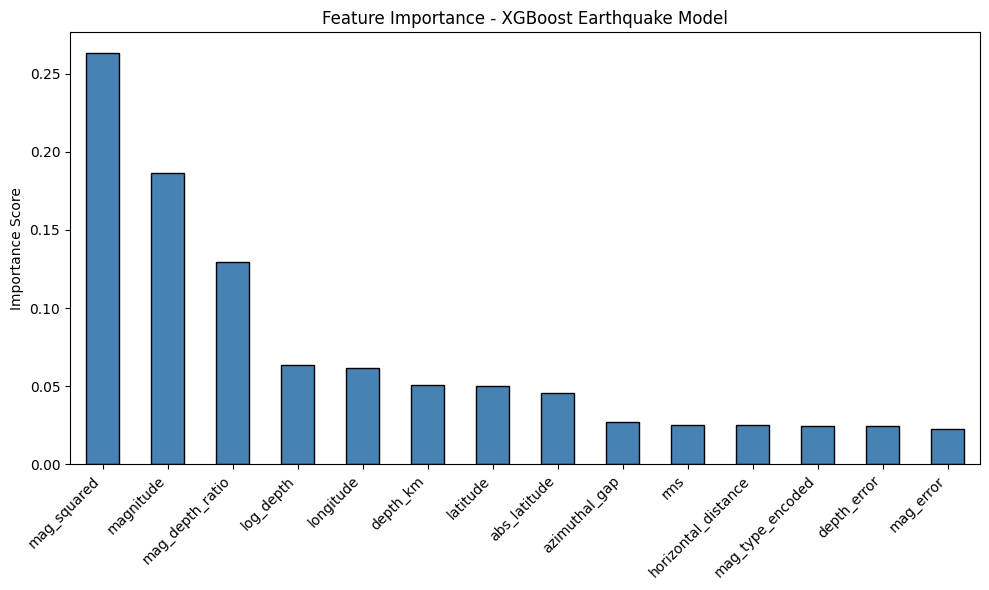

✅ Feature importance plotted!

Top features:
  mag_squared              : 0.2634
  magnitude                : 0.1864
  mag_depth_ratio          : 0.1297
  log_depth                : 0.0635
  longitude                : 0.0619


In [13]:
# ✅ STEP 11: Feature Importance (What matters most?)

feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance - XGBoost Earthquake Model')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('✅ Feature importance plotted!')
print('\nTop features:')
for feat, imp in feat_imp.head(5).items():
    print(f'  {feat:25s}: {imp:.4f}')

In [15]:
# ✅ STEP 12: LIVE PREDICTION - Demo
# FIXED: Now uses only the features the model was actually trained on

def predict_earthquake_damage(magnitude, depth_km, latitude, longitude,
                               depth_error=5.0, mag_error=0.1,
                               azimuthal_gap=50.0, horizontal_distance=1.0,
                               rms=0.8, mag_type='MW'):
    """
    Predict earthquake damage level.
    Uses the same features the model was trained on.
    """
    # Engineer the same features used during training
    abs_latitude = abs(latitude)
    mag_depth_ratio = magnitude / (depth_km + 1)
    log_depth = np.log1p(depth_km)
    mag_squared = magnitude ** 2

    # Encode mag_type (use transform if known, else default)
    try:
        mag_type_encoded = le_mag_type.transform([mag_type])[0]
    except ValueError:
        mag_type_encoded = 0  # Default for unknown types

    input_data = pd.DataFrame([{
        'magnitude': magnitude,
        'depth_km': depth_km,
        'latitude': latitude,
        'longitude': longitude,
        'abs_latitude': abs_latitude,
        'mag_depth_ratio': mag_depth_ratio,
        'log_depth': log_depth,
        'mag_squared': mag_squared,
        'depth_error': depth_error,
        'mag_error': mag_error,
        'azimuthal_gap': azimuthal_gap,
        'horizontal_distance': horizontal_distance,
        'rms': rms,
        'mag_type_encoded': mag_type_encoded
    }])

    prediction = xgb_model.predict(input_data)[0]
    probability = xgb_model.predict_proba(input_data)[0]

    labels = {0: '🟢 LOW', 1: '🟡 MEDIUM', 2: '🔴 HIGH'}

    print('=' * 50)
    print('🌍 EARTHQUAKE DAMAGE PREDICTION RESULT')
    print('=' * 50)
    print(f'  Magnitude       : {magnitude}')
    print(f'  Depth           : {depth_km} km')
    print(f'  Location        : ({latitude:.1f}, {longitude:.1f})')
    print(f'  Magnitude Type  : {mag_type}')
    print('-' * 50)
    print(f'  DAMAGE LEVEL    : {labels[prediction]}')
    print(f'  Confidence      : {max(probability)*100:.1f}%')
    print(f'  Low Risk Prob   : {probability[0]*100:.1f}%')
    print(f'  Medium Risk Prob: {probability[1]*100:.1f}%')
    print(f'  High Risk Prob  : {probability[2]*100:.1f}%')
    print('=' * 50)

# ---- TEST CASES ----

# Test 1: High Risk Scenario (shallow, high magnitude)
predict_earthquake_damage(
    magnitude=7.8, depth_km=10, latitude=28.6, longitude=77.2
)

print()

# Test 2: Low Risk Scenario (deep, moderate magnitude)
predict_earthquake_damage(
    magnitude=5.5, depth_km=500, latitude=22.0, longitude=80.0
)

🌍 EARTHQUAKE DAMAGE PREDICTION RESULT
  Magnitude       : 7.8
  Depth           : 10 km
  Location        : (28.6, 77.2)
  Magnitude Type  : MW
--------------------------------------------------
  DAMAGE LEVEL    : 🔴 HIGH
  Confidence      : 99.8%
  Low Risk Prob   : 0.1%
  Medium Risk Prob: 0.1%
  High Risk Prob  : 99.8%

🌍 EARTHQUAKE DAMAGE PREDICTION RESULT
  Magnitude       : 5.5
  Depth           : 500 km
  Location        : (22.0, 80.0)
  Magnitude Type  : MW
--------------------------------------------------
  DAMAGE LEVEL    : 🟢 LOW
  Confidence      : 100.0%
  Low Risk Prob   : 100.0%
  Medium Risk Prob: 0.0%
  High Risk Prob  : 0.0%


In [16]:
import joblib
from google.colab import drive

# Drive mount karo
drive.mount('/content/drive')

# Folder banao
import os
os.makedirs('/content/drive/MyDrive/disaster_models', exist_ok=True)


joblib.dump(xgb_model, '/content/drive/MyDrive/disaster_models/earthquake_xgb_model.pkl')
joblib.dump(rf_model,  '/content/drive/MyDrive/disaster_models/earthquake_rf_model.pkl')

print('✅ Models saved to Google Drive!')

Mounted at /content/drive
✅ Models saved to Google Drive!
